# Combined NIH + Kaggle Dataset Preparation Notebook
This notebook loads the NIH and Kaggle datasets, performs basic checks and exploratory review, extracts NIH binary classes, and creates a combined dataset.

In [18]:
# Import libraries used for file handling, image checks, hashing, and summaries

import os
import shutil
import hashlib
import random
from pathlib import Path
from collections import Counter

import pandas as pd
from PIL import Image, ImageStat
import matplotlib.pyplot as plt

In [19]:
# Set project paths and create output folders

project_root = r"C:\Users\teren\Documents\AI in healthcare\project_final"

nih_root = os.path.join(project_root, "nih")
kaggle_root = os.path.join(project_root, "kaggle")

nih_csv_path = os.path.join(nih_root, "Data_Entry_2017.csv")

nih_binary_root = os.path.join(project_root, "nih_binary_dataset")
nih_normal_output = os.path.join(nih_binary_root, "NORMAL")
nih_pneumonia_output = os.path.join(nih_binary_root, "PNEUMONIA")

combined_root = os.path.join(project_root, "combined_dataset")
combined_normal_output = os.path.join(combined_root, "NORMAL")
combined_pneumonia_output = os.path.join(combined_root, "PNEUMONIA")

report_dir = os.path.join(combined_root, "reports")

valid_exts = (".png", ".jpg", ".jpeg")

os.makedirs(nih_normal_output, exist_ok=True)
os.makedirs(nih_pneumonia_output, exist_ok=True)
os.makedirs(combined_normal_output, exist_ok=True)
os.makedirs(combined_pneumonia_output, exist_ok=True)
os.makedirs(report_dir, exist_ok=True)

print("Folders ready.")

Folders ready.


In [20]:

# Define helper functions for listing images, hashing files, checking corruption, and duplicate detection

def list_images(folder):
    if not os.path.exists(folder):
        return []
    return sorted([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(valid_exts)
    ])


def verify_images(folder):
    corrupted = []
    for fname in list_images(folder):
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()
        except Exception:
            corrupted.append(fname)
    return corrupted


def md5_hash(filepath, chunk_size=8192):
    h = hashlib.md5()
    with open(filepath, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def duplicate_check_with_hashes(folder):
    seen_hashes = {}
    duplicates = []

    for fname in list_images(folder):
        fpath = os.path.join(folder, fname)
        try:
            file_hash = md5_hash(fpath)
            if file_hash in seen_hashes:
                duplicates.append((seen_hashes[file_hash], fname, file_hash))
            else:
                seen_hashes[file_hash] = fname
        except Exception:
            pass

    return duplicates


def image_size_check(folder):
    rows = []
    for fname in list_images(folder):
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                rows.append((fname, img.size[0], img.size[1], img.mode))
        except Exception:
            pass
    return rows


def low_quality_check(folder, sample_limit=200):
    suspicious = []
    files = list_images(folder)[:sample_limit]

    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            with Image.open(fpath) as img:
                gray = img.convert("L")
                stat = ImageStat.Stat(gray)
                stddev = stat.stddev[0]

                pixels = list(gray.getdata())
                n = len(pixels)

                black_ratio = sum(p <= 5 for p in pixels) / n
                white_ratio = sum(p >= 250 for p in pixels) / n

                if stddev < 8 or black_ratio > 0.90 or white_ratio > 0.90:
                    suspicious.append({
                        "file": fname,
                        "stddev": round(stddev, 2),
                        "black_ratio": round(black_ratio, 4),
                        "white_ratio": round(white_ratio, 4)
                    })
        except Exception:
            pass

    return suspicious


def clear_folder(folder):
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)


def show_sample_images(folder, class_name, n=6):
    files = list_images(folder)[:n]

    if len(files) == 0:
        print(f"No images found in {folder}")
        return

    plt.figure(figsize=(12, 6))
    for i, fname in enumerate(files, 1):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath)
            plt.subplot(2, 3, i)
            plt.imshow(img, cmap="gray")
            plt.title(class_name)
            plt.axis("off")
        except Exception:
            pass

    plt.tight_layout()
    plt.show()

In [21]:

# Check whether the expected NIH and Kaggle folders exist

print("Checking dataset folders...\n")

print("NIH root exists:", os.path.exists(nih_root))
print("Kaggle root exists:", os.path.exists(kaggle_root))
print("NIH CSV exists:", os.path.exists(nih_csv_path))

print("\nKaggle NORMAL exists:", os.path.exists(os.path.join(kaggle_root, "NORMAL")))
print("Kaggle PNEUMONIA exists:", os.path.exists(os.path.join(kaggle_root, "PNEUMONIA")))

Checking dataset folders...

NIH root exists: True
Kaggle root exists: True
NIH CSV exists: True

Kaggle NORMAL exists: True
Kaggle PNEUMONIA exists: True


In [22]:

# Load NIH metadata and filter exact binary classes only

df = pd.read_csv(nih_csv_path)

print("CSV loaded successfully.")
print("Columns:")
print(df.columns.tolist())

nih_normal_df = df[df["Finding Labels"] == "No Finding"].copy()
nih_pneumonia_df = df[df["Finding Labels"] == "Pneumonia"].copy()

print("\nNIH exact NORMAL rows:", len(nih_normal_df))
print("NIH exact PNEUMONIA rows:", len(nih_pneumonia_df))

CSV loaded successfully.
Columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

NIH exact NORMAL rows: 60361
NIH exact PNEUMONIA rows: 322


In [23]:

# Index all NIH images so they can be found and copied by image name

image_map = {}

for path in Path(nih_root).rglob("*"):
    if path.suffix.lower() in valid_exts:
        image_map[path.name] = str(path)

print("Total NIH image files indexed:", len(image_map))

Total NIH image files indexed: 112118


In [24]:

# Clear old NIH binary output folders before copying fresh files

clear_folder(nih_normal_output)
clear_folder(nih_pneumonia_output)

print("NIH binary folders cleared and recreated.")

NIH binary folders cleared and recreated.


In [25]:
# Copy all exact NIH NORMAL and NIH PNEUMONIA images into binary folders

missing_normal = []
copied_normal = 0

for img_name in nih_normal_df["Image Index"]:
    src = image_map.get(img_name)
    if src:
        shutil.copy2(src, os.path.join(nih_normal_output, img_name))
        copied_normal += 1
    else:
        missing_normal.append(img_name)

missing_pneumonia = []
copied_pneumonia = 0

for img_name in nih_pneumonia_df["Image Index"]:
    src = image_map.get(img_name)
    if src:
        shutil.copy2(src, os.path.join(nih_pneumonia_output, img_name))
        copied_pneumonia += 1
    else:
        missing_pneumonia.append(img_name)

print("NIH extraction complete.")
print("Copied NIH NORMAL:", copied_normal)
print("Copied NIH PNEUMONIA:", copied_pneumonia)
print("Missing NIH NORMAL:", len(missing_normal))
print("Missing NIH PNEUMONIA:", len(missing_pneumonia))

NIH extraction complete.
Copied NIH NORMAL: 60359
Copied NIH PNEUMONIA: 322
Missing NIH NORMAL: 2
Missing NIH PNEUMONIA: 0


In [26]:
# Save NIH extraction summary and missing-file reports

nih_extraction_summary = pd.DataFrame({
    "class": ["NORMAL", "PNEUMONIA"],
    "expected_from_csv": [len(nih_normal_df), len(nih_pneumonia_df)],
    "copied": [copied_normal, copied_pneumonia],
    "missing": [len(missing_normal), len(missing_pneumonia)]
})

nih_extraction_summary.to_csv(
    os.path.join(nih_binary_root, "extraction_summary.csv"),
    index=False
)

pd.DataFrame({"missing_normal": missing_normal}).to_csv(
    os.path.join(nih_binary_root, "missing_normal.csv"),
    index=False
)

pd.DataFrame({"missing_pneumonia": missing_pneumonia}).to_csv(
    os.path.join(nih_binary_root, "missing_pneumonia.csv"),
    index=False
)

nih_extraction_summary

,class,expected_from_csv,copied,missing
0,NORMAL,60361,60359,2
1,PNEUMONIA,322,322,0


In [27]:

# Randomly sample 500 NIH NORMAL images to balance the normal class contribution

random.seed(42)

nih_normal_files = list_images(nih_normal_output)
nih_pneumonia_files = list_images(nih_pneumonia_output)

sample_size = min(500, len(nih_normal_files))
sampled_nih_normal_files = random.sample(nih_normal_files, sample_size)

print("Total extracted NIH NORMAL images:", len(nih_normal_files))
print("Sampled NIH NORMAL images:", len(sampled_nih_normal_files))
print("Total extracted NIH PNEUMONIA images:", len(nih_pneumonia_files))

Total extracted NIH NORMAL images: 60359
Sampled NIH NORMAL images: 500
Total extracted NIH PNEUMONIA images: 322


In [28]:
# Save the sampled NIH normal file list for reproducibility

sampled_nih_normal_df = pd.DataFrame({"file": sampled_nih_normal_files})
sampled_nih_normal_df.to_csv(
    os.path.join(nih_binary_root, "sampled_500_nih_normal_files.csv"),
    index=False
)

sampled_nih_normal_df.head()

,file
0,00018614_005.png
1,00003276_000.png
2,00000820_008.png
3,00022359_000.png
4,00008051_049.png


In [29]:

# Run basic quality checks on Kaggle and NIH folders before combining

kaggle_normal_folder = os.path.join(kaggle_root, "NORMAL")
kaggle_pneumonia_folder = os.path.join(kaggle_root, "PNEUMONIA")

print("Corrupted Kaggle NORMAL:", len(verify_images(kaggle_normal_folder)))
print("Corrupted Kaggle PNEUMONIA:", len(verify_images(kaggle_pneumonia_folder)))
print("Corrupted NIH NORMAL:", len(verify_images(nih_normal_output)))
print("Corrupted NIH PNEUMONIA:", len(verify_images(nih_pneumonia_output)))

Corrupted Kaggle NORMAL: 0
Corrupted Kaggle PNEUMONIA: 0
Corrupted NIH NORMAL: 0
Corrupted NIH PNEUMONIA: 0


In [30]:
# Check duplicates within each dataset folder using file hashes

kaggle_normal_duplicates = duplicate_check_with_hashes(kaggle_normal_folder)
kaggle_pneumonia_duplicates = duplicate_check_with_hashes(kaggle_pneumonia_folder)

nih_normal_duplicates = duplicate_check_with_hashes(nih_normal_output)
nih_pneumonia_duplicates = duplicate_check_with_hashes(nih_pneumonia_output)

print("Kaggle NORMAL duplicates:", len(kaggle_normal_duplicates))
print("Kaggle PNEUMONIA duplicates:", len(kaggle_pneumonia_duplicates))
print("NIH NORMAL duplicates:", len(nih_normal_duplicates))
print("NIH PNEUMONIA duplicates:", len(nih_pneumonia_duplicates))

Kaggle NORMAL duplicates: 4
Kaggle PNEUMONIA duplicates: 28
NIH NORMAL duplicates: 0
NIH PNEUMONIA duplicates: 0


In [31]:

# Save duplicate reports found within each individual folder

pd.DataFrame(kaggle_normal_duplicates, columns=["original_file", "duplicate_file", "hash"]).to_csv(
    os.path.join(report_dir, "kaggle_normal_duplicates.csv"), index=False
)

pd.DataFrame(kaggle_pneumonia_duplicates, columns=["original_file", "duplicate_file", "hash"]).to_csv(
    os.path.join(report_dir, "kaggle_pneumonia_duplicates.csv"), index=False
)

pd.DataFrame(nih_normal_duplicates, columns=["original_file", "duplicate_file", "hash"]).to_csv(
    os.path.join(report_dir, "nih_normal_duplicates.csv"), index=False
)

pd.DataFrame(nih_pneumonia_duplicates, columns=["original_file", "duplicate_file", "hash"]).to_csv(
    os.path.join(report_dir, "nih_pneumonia_duplicates.csv"), index=False
)

print("Within-folder duplicate reports saved.")

Within-folder duplicate reports saved.


In [32]:

# Build hash maps for Kaggle and NIH so cross-dataset duplicate images can be found

def build_hash_map(folder, selected_files=None):
    hash_map = {}
    files = selected_files if selected_files is not None else list_images(folder)

    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            file_hash = md5_hash(fpath)
            hash_map[fname] = file_hash
        except Exception:
            pass

    return hash_map


kaggle_normal_hashes = build_hash_map(kaggle_normal_folder)
kaggle_pneumonia_hashes = build_hash_map(kaggle_pneumonia_folder)

sampled_nih_normal_hashes = build_hash_map(nih_normal_output, sampled_nih_normal_files)
nih_pneumonia_hashes = build_hash_map(nih_pneumonia_output)

In [33]:

# Compare Kaggle and NIH NORMAL images to detect same image files across datasets

kaggle_normal_hash_to_file = {v: k for k, v in kaggle_normal_hashes.items()}
nih_normal_hash_to_file = {v: k for k, v in sampled_nih_normal_hashes.items()}

cross_normal_duplicates = []
for file_hash, nih_file in nih_normal_hash_to_file.items():
    if file_hash in kaggle_normal_hash_to_file:
        cross_normal_duplicates.append({
            "kaggle_file": kaggle_normal_hash_to_file[file_hash],
            "nih_file": nih_file,
            "hash": file_hash
        })

cross_normal_duplicates_df = pd.DataFrame(cross_normal_duplicates)
cross_normal_duplicates_df.to_csv(
    os.path.join(report_dir, "cross_dataset_normal_duplicates.csv"),
    index=False
)

print("Cross-dataset NORMAL duplicates:", len(cross_normal_duplicates_df))
cross_normal_duplicates_df.head()

Cross-dataset NORMAL duplicates: 0


""


In [34]:

# Compare Kaggle and NIH PNEUMONIA images to detect same image files across datasets

kaggle_pneumonia_hash_to_file = {v: k for k, v in kaggle_pneumonia_hashes.items()}
nih_pneumonia_hash_to_file = {v: k for k, v in nih_pneumonia_hashes.items()}

cross_pneumonia_duplicates = []
for file_hash, nih_file in nih_pneumonia_hash_to_file.items():
    if file_hash in kaggle_pneumonia_hash_to_file:
        cross_pneumonia_duplicates.append({
            "kaggle_file": kaggle_pneumonia_hash_to_file[file_hash],
            "nih_file": nih_file,
            "hash": file_hash
        })

cross_pneumonia_duplicates_df = pd.DataFrame(cross_pneumonia_duplicates)
cross_pneumonia_duplicates_df.to_csv(
    os.path.join(report_dir, "cross_dataset_pneumonia_duplicates.csv"),
    index=False
)

print("Cross-dataset PNEUMONIA duplicates:", len(cross_pneumonia_duplicates_df))
cross_pneumonia_duplicates_df.head()

Cross-dataset PNEUMONIA duplicates: 0


""


In [35]:

# Remove NIH files that match Kaggle files so the final merged dataset does not keep repeated images

nih_normal_files_to_exclude = set(cross_normal_duplicates_df["nih_file"]) if len(cross_normal_duplicates_df) > 0 else set()
nih_pneumonia_files_to_exclude = set(cross_pneumonia_duplicates_df["nih_file"]) if len(cross_pneumonia_duplicates_df) > 0 else set()

final_sampled_nih_normal_files = [
    f for f in sampled_nih_normal_files
    if f not in nih_normal_files_to_exclude
]

final_nih_pneumonia_files = [
    f for f in nih_pneumonia_files
    if f not in nih_pneumonia_files_to_exclude
]

print("Sampled NIH NORMAL before duplicate removal:", len(sampled_nih_normal_files))
print("Sampled NIH NORMAL after duplicate removal:", len(final_sampled_nih_normal_files))

print("NIH PNEUMONIA before duplicate removal:", len(nih_pneumonia_files))
print("NIH PNEUMONIA after duplicate removal:", len(final_nih_pneumonia_files))

Sampled NIH NORMAL before duplicate removal: 500
Sampled NIH NORMAL after duplicate removal: 500
NIH PNEUMONIA before duplicate removal: 322
NIH PNEUMONIA after duplicate removal: 322


In [36]:

# Clear the final combined dataset folders before creating the final merged dataset

clear_folder(combined_normal_output)
clear_folder(combined_pneumonia_output)

print("Combined dataset folders cleared.")

Combined dataset folders cleared.


In [37]:

# Copy all Kaggle NORMAL images into the final combined NORMAL folder

for fname in list_images(kaggle_normal_folder):
    src = os.path.join(kaggle_normal_folder, fname)
    dst = os.path.join(combined_normal_output, f"kaggle_{fname}")
    shutil.copy2(src, dst)

print("Kaggle NORMAL copied:", len(list_images(kaggle_normal_folder)))

Kaggle NORMAL copied: 1583


In [38]:

# Copy sampled and deduplicated NIH NORMAL images into the final combined NORMAL folder

for fname in final_sampled_nih_normal_files:
    src = os.path.join(nih_normal_output, fname)
    dst = os.path.join(combined_normal_output, f"nih_{fname}")
    shutil.copy2(src, dst)

print("NIH NORMAL copied after sampling and duplicate removal:", len(final_sampled_nih_normal_files))

NIH NORMAL copied after sampling and duplicate removal: 500


In [39]:

# Copy all Kaggle PNEUMONIA images into the final combined PNEUMONIA folder

for fname in list_images(kaggle_pneumonia_folder):
    src = os.path.join(kaggle_pneumonia_folder, fname)
    dst = os.path.join(combined_pneumonia_output, f"kaggle_{fname}")
    shutil.copy2(src, dst)

print("Kaggle PNEUMONIA copied:", len(list_images(kaggle_pneumonia_folder)))

Kaggle PNEUMONIA copied: 4273


In [40]:

# Copy deduplicated NIH PNEUMONIA images into the final combined PNEUMONIA folder

for fname in final_nih_pneumonia_files:
    src = os.path.join(nih_pneumonia_output, fname)
    dst = os.path.join(combined_pneumonia_output, f"nih_{fname}")
    shutil.copy2(src, dst)

print("NIH PNEUMONIA copied after duplicate removal:", len(final_nih_pneumonia_files))

NIH PNEUMONIA copied after duplicate removal: 322


In [41]:

# Check final combined dataset for corruption, duplicates, and size information

final_normal_corrupted = verify_images(combined_normal_output)
final_pneumonia_corrupted = verify_images(combined_pneumonia_output)

final_normal_duplicates = duplicate_check_with_hashes(combined_normal_output)
final_pneumonia_duplicates = duplicate_check_with_hashes(combined_pneumonia_output)

final_normal_sizes = image_size_check(combined_normal_output)
final_pneumonia_sizes = image_size_check(combined_pneumonia_output)

print("Final combined NORMAL corrupted:", len(final_normal_corrupted))
print("Final combined PNEUMONIA corrupted:", len(final_pneumonia_corrupted))
print("Final combined NORMAL duplicates:", len(final_normal_duplicates))
print("Final combined PNEUMONIA duplicates:", len(final_pneumonia_duplicates))

Final combined NORMAL corrupted: 0
Final combined PNEUMONIA corrupted: 0
Final combined NORMAL duplicates: 4
Final combined PNEUMONIA duplicates: 28


In [42]:
# Save final image size information and low-resolution flags

size_rows = []

for fname, w, h, mode in final_normal_sizes:
    size_rows.append({
        "class": "NORMAL",
        "file": fname,
        "width": w,
        "height": h,
        "mode": mode
    })

for fname, w, h, mode in final_pneumonia_sizes:
    size_rows.append({
        "class": "PNEUMONIA",
        "file": fname,
        "width": w,
        "height": h,
        "mode": mode
    })

final_size_df = pd.DataFrame(size_rows)
final_size_df.to_csv(
    os.path.join(report_dir, "final_combined_image_sizes.csv"),
    index=False
)

low_res_df = final_size_df[
    (final_size_df["width"] < 224) | (final_size_df["height"] < 224)
]
low_res_df.to_csv(
    os.path.join(report_dir, "final_combined_low_resolution.csv"),
    index=False
)

print("Final size report saved.")
print("Low-resolution images flagged:", len(low_res_df))

Final size report saved.
Low-resolution images flagged: 41


In [43]:

# Run a sample-based low-quality check on the final combined dataset

normal_suspicious = low_quality_check(combined_normal_output, sample_limit=200)
pneumonia_suspicious = low_quality_check(combined_pneumonia_output, sample_limit=200)

normal_suspicious_df = pd.DataFrame(normal_suspicious)
normal_suspicious_df["class"] = "NORMAL"

pneumonia_suspicious_df = pd.DataFrame(pneumonia_suspicious)
pneumonia_suspicious_df["class"] = "PNEUMONIA"

final_suspicious_df = pd.concat(
    [normal_suspicious_df, pneumonia_suspicious_df],
    ignore_index=True
)

final_suspicious_df.to_csv(
    os.path.join(report_dir, "final_combined_suspicious_images.csv"),
    index=False
)

print("Suspicious final images flagged:", len(final_suspicious_df))
final_suspicious_df.head()

C:\Users\teren\AppData\Local\Temp\ipykernel_45768\4286365733.py:77: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  pixels = list(gray.getdata())


Suspicious final images flagged: 0


,class


In [44]:

# Check whether the same image appears in both final NORMAL and final PNEUMONIA folders

final_normal_hashes = {}
for fname in list_images(combined_normal_output):
    fpath = os.path.join(combined_normal_output, fname)
    try:
        final_normal_hashes[md5_hash(fpath)] = fname
    except Exception:
        pass

cross_class_duplicates = []
for fname in list_images(combined_pneumonia_output):
    fpath = os.path.join(combined_pneumonia_output, fname)
    try:
        h = md5_hash(fpath)
        if h in final_normal_hashes:
            cross_class_duplicates.append({
                "normal_file": final_normal_hashes[h],
                "pneumonia_file": fname,
                "hash": h
            })
    except Exception:
        pass

cross_class_duplicates_df = pd.DataFrame(cross_class_duplicates)
cross_class_duplicates_df.to_csv(
    os.path.join(report_dir, "final_cross_class_duplicates.csv"),
    index=False
)

print("Cross-class duplicates in final dataset:", len(cross_class_duplicates_df))
cross_class_duplicates_df.head()

Cross-class duplicates in final dataset: 0


""


In [45]:

# Save final duplicate and corruption reports

pd.DataFrame(final_normal_corrupted, columns=["corrupted_file"]).to_csv(
    os.path.join(report_dir, "final_normal_corrupted.csv"),
    index=False
)

pd.DataFrame(final_pneumonia_corrupted, columns=["corrupted_file"]).to_csv(
    os.path.join(report_dir, "final_pneumonia_corrupted.csv"),
    index=False
)

pd.DataFrame(final_normal_duplicates, columns=["original_file", "duplicate_file", "hash"]).to_csv(
    os.path.join(report_dir, "final_normal_duplicates.csv"),
    index=False
)

pd.DataFrame(final_pneumonia_duplicates, columns=["original_file", "duplicate_file", "hash"]).to_csv(
    os.path.join(report_dir, "final_pneumonia_duplicates.csv"),
    index=False
)

print("Final corruption and duplicate reports saved.")

Final corruption and duplicate reports saved.


In [46]:

# Build a final summary table showing how the combined dataset was created

final_summary = pd.DataFrame({
    "class": ["NORMAL", "PNEUMONIA"],
    "kaggle_count": [
        len(list_images(kaggle_normal_folder)),
        len(list_images(kaggle_pneumonia_folder))
    ],
    "nih_before_sampling_or_removal": [
        len(nih_normal_files),
        len(nih_pneumonia_files)
    ],
    "nih_after_sampling_or_removal": [
        len(final_sampled_nih_normal_files),
        len(final_nih_pneumonia_files)
    ],
    "final_combined_count": [
        len(list_images(combined_normal_output)),
        len(list_images(combined_pneumonia_output))
    ]
})

final_summary.to_csv(
    os.path.join(report_dir, "final_combined_dataset_summary.csv"),
    index=False
)

final_summary

,class,kaggle_count,nih_before_sampling_or_removal,nih_after_sampling_or_removal,final_combined_count
0,NORMAL,1583,60359,500,2083
1,PNEUMONIA,4273,322,322,4595


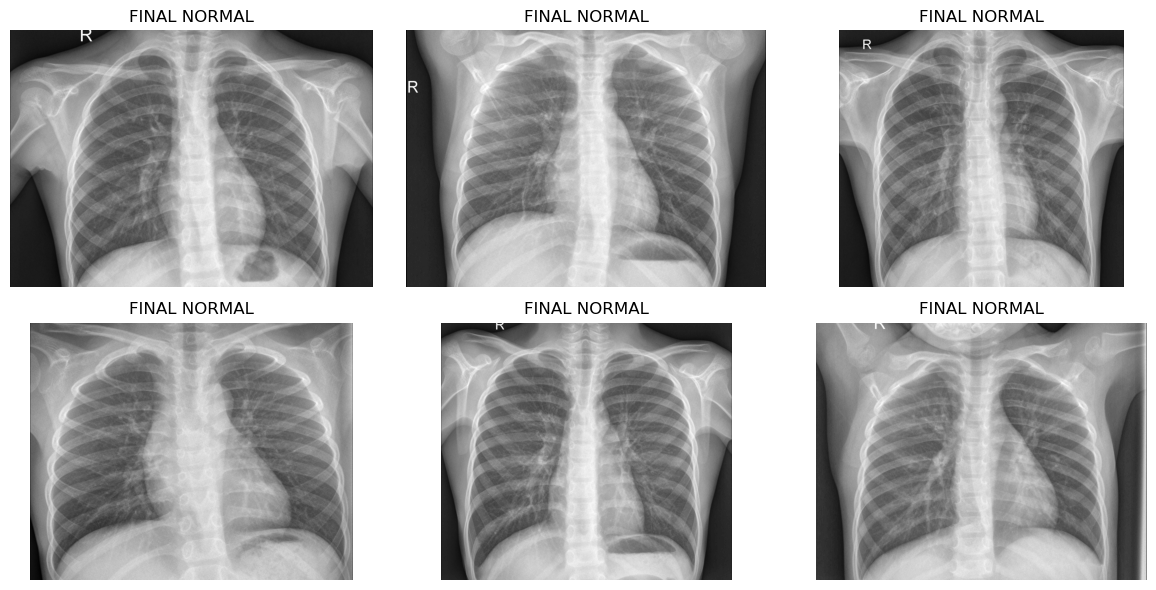

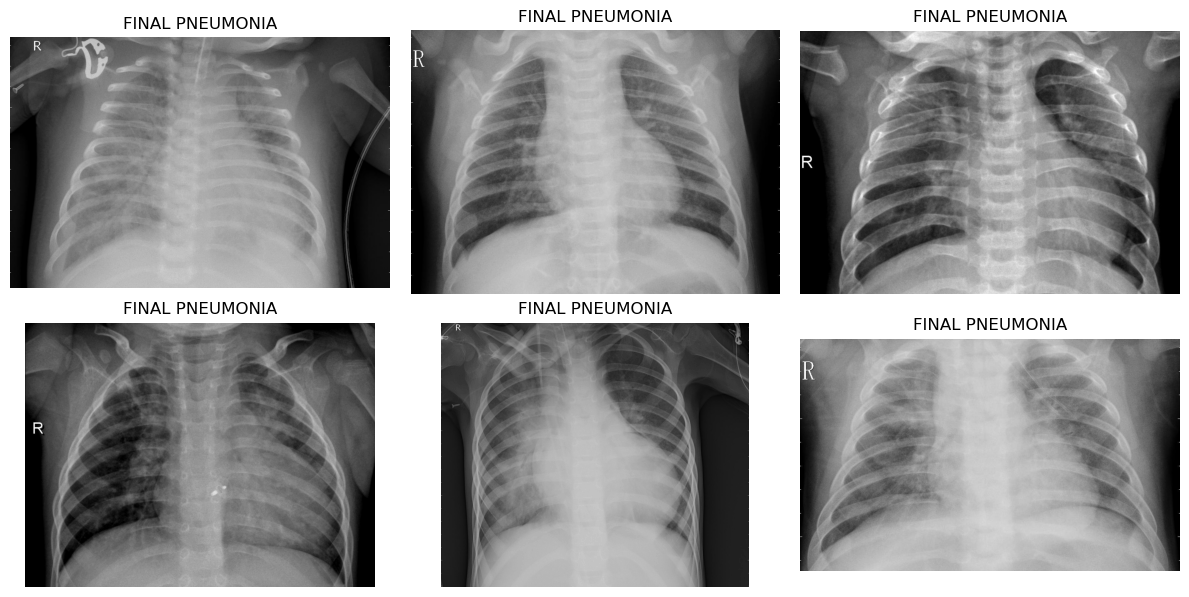

In [47]:

# Show a few sample images from the final combined dataset

show_sample_images(combined_normal_output, "FINAL NORMAL")
show_sample_images(combined_pneumonia_output, "FINAL PNEUMONIA")

In [48]:

# Print final folder counts and locations

print("Final combined dataset created successfully.\n")
print("FINAL NORMAL count:", len(list_images(combined_normal_output)))
print("FINAL PNEUMONIA count:", len(list_images(combined_pneumonia_output)))

print("\nFinal NORMAL folder:")
print(combined_normal_output)

print("\nFinal PNEUMONIA folder:")
print(combined_pneumonia_output)

print("\nReports folder:")
print(report_dir)

Final combined dataset created successfully.

FINAL NORMAL count: 2083
FINAL PNEUMONIA count: 4595

Final NORMAL folder:
C:\Users\teren\Documents\AI in healthcare\project_final\combined_dataset\NORMAL

Final PNEUMONIA folder:
C:\Users\teren\Documents\AI in healthcare\project_final\combined_dataset\PNEUMONIA

Reports folder:
C:\Users\teren\Documents\AI in healthcare\project_final\combined_dataset\reports


In [49]:
# Create one parent folder called combined_dataset
# Then place NORMAL and PNEUMONIA inside it

combined_root = os.path.join(project_root, "combined_dataset")
combined_normal_output = os.path.join(combined_root, "NORMAL")
combined_pneumonia_output = os.path.join(combined_root, "PNEUMONIA")

os.makedirs(combined_normal_output, exist_ok=True)
os.makedirs(combined_pneumonia_output, exist_ok=True)

print("Created:")
print(combined_root)
print(combined_normal_output)
print(combined_pneumonia_output)

Created:
C:\Users\teren\Documents\AI in healthcare\project_final\combined_dataset
C:\Users\teren\Documents\AI in healthcare\project_final\combined_dataset\NORMAL
C:\Users\teren\Documents\AI in healthcare\project_final\combined_dataset\PNEUMONIA


In [50]:
# Clear old combined dataset folders first
# Then copy Kaggle and NIH images into the same parent folder

def clear_folder(folder):
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)

clear_folder(combined_normal_output)
clear_folder(combined_pneumonia_output)

# Copy NORMAL images
for fname in list_images(kaggle_normal_folder):
    src = os.path.join(kaggle_normal_folder, fname)
    dst = os.path.join(combined_normal_output, f"kaggle_{fname}")
    shutil.copy2(src, dst)

for fname in final_sampled_nih_normal_files:
    src = os.path.join(nih_normal_output, fname)
    dst = os.path.join(combined_normal_output, f"nih_{fname}")
    shutil.copy2(src, dst)

# Copy PNEUMONIA images
for fname in list_images(kaggle_pneumonia_folder):
    src = os.path.join(kaggle_pneumonia_folder, fname)
    dst = os.path.join(combined_pneumonia_output, f"kaggle_{fname}")
    shutil.copy2(src, dst)

for fname in final_nih_pneumonia_files:
    src = os.path.join(nih_pneumonia_output, fname)
    dst = os.path.join(combined_pneumonia_output, f"nih_{fname}")
    shutil.copy2(src, dst)

print("Final combined dataset created successfully.")
print("Parent folder:", combined_root)
print("NORMAL count:", len(list_images(combined_normal_output)))
print("PNEUMONIA count:", len(list_images(combined_pneumonia_output)))

Final combined dataset created successfully.
Parent folder: C:\Users\teren\Documents\AI in healthcare\project_final\combined_dataset
NORMAL count: 2083
PNEUMONIA count: 4595
